# 🏦 AML Risk Detection — Unsupervised Anomaly Detection + GNN
## IBM Synthetic + Czech Financial Datasets (Merged)

---

### Core Philosophy

In real-world AML (Anti-Money Laundering), **confirmed laundering labels are extremely rare**. Banks process millions of transactions daily, but only a tiny fraction are ever confirmed as illicit. This makes **unsupervised anomaly detection** the most realistic and practical approach.

### Why NOT Pseudo-Labeling?

A teacher model trained on synthetic IBM data would:
- Learn **synthetic patterns** that don't exist in real Czech bank data
- Generate **biased pseudo-labels** that compound errors
- Create **distribution shift** — the student inherits the teacher's blind spots
- Give a **false sense of accuracy** — the model just learns its own mistakes

### Our Strategy Instead

```
┌──────────────────────────────────────────────────────────────────┐
│  DATA LAYER                                                     │
│  IBM AML (labeled) + Czech Financial (unlabeled)                │
│      ↓ Schema Harmonization + Concatenation                     │
│      ↓ Feature Engineering (transaction + account + graph)      │
├──────────────────────────────────────────────────────────────────┤
│  UNSUPERVISED MODELS (trained on ALL data, ZERO labels):        │
│    • Isolation Forest        — tree-based anomaly isolation     │
│    • Local Outlier Factor    — density-based local anomalies    │
│    • K-Means Distance        — cluster-distance anomaly proxy  │
│    • Autoencoder (NN)        — reconstruction error anomaly    │
│    • GNN Autoencoder         — graph-structure-aware anomaly   │
│    • Ensemble                — normalized average of all       │
├──────────────────────────────────────────────────────────────────┤
│  EVALUATION (labels used ONLY here, never in training):         │
│    • IBM 'Is Laundering' as ground truth                        │
│    • ROC-AUC, PR-AUC, Precision@K, F1@optimal threshold        │
│    • Sankey flow diagrams, network graphs, PCA projections      │
└──────────────────────────────────────────────────────────────────┘
```

### Datasets

| Dataset | Source | Rows | Role | Label |
|---------|--------|------|------|-------|
| IBM Synthetic AML (HI-Small) | Kaggle | ~500K | Labeled transactions | `Is Laundering` 0/1 |
| Czech Financial (1999) | Kaggle | ~1M | Real-world banking | Loan status proxy |

### Deliverables
- 6 unsupervised anomaly detection models
- Graph Neural Network (GNN) for structural anomaly detection
- Sankey money flow diagrams
- 5 network graph visualizations
- 18+ total figures
- Account-level risk scoring
- Comprehensive evaluation with held-out labels

---
## 0. Setup & Installation

In [ ]:
!pip install -q kagglehub xgboost networkx plotly

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

!pip install -q torch-geometric

PyTorch version: 2.10.0+cu128
CUDA available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import os, glob, warnings, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, f1_score, precision_score,
    recall_score, roc_curve, auc
)

import torch
import torch.nn.functional as F

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ All imports loaded! Device: {DEVICE}')

✅ All imports loaded! Device: cuda


---
## 1. Download Both Datasets

In [ ]:
import kagglehub

print("📥 Downloading IBM AML dataset...")
ibm_path = kagglehub.dataset_download("ealtman2019/ibm-transactions-for-anti-money-laundering-aml")
print(f"  Path: {ibm_path}")
for f in sorted(os.listdir(ibm_path)):
    sz = os.path.getsize(os.path.join(ibm_path, f)) / (1024*1024)
    print(f"    {f} ({sz:.1f} MB)")

print("\n📥 Downloading Czech Financial dataset...")
czech_path = kagglehub.dataset_download("siavashraz/1999-czech-financial-dataset")
print(f"  Path: {czech_path}")
for root, dirs, files in os.walk(czech_path):
    for f in files:
        fp = os.path.join(root, f)
        sz = os.path.getsize(fp) / (1024*1024)
        print(f"    {os.path.relpath(fp, czech_path)} ({sz:.1f} MB)")

📥 Downloading IBM AML dataset...
Using Colab cache for faster access to the 'ibm-transactions-for-anti-money-laundering-aml' dataset.
  Path: /kaggle/input/ibm-transactions-for-anti-money-laundering-aml
    HI-Large_Patterns.txt (13.2 MB)
    HI-Large_Trans.csv (16262.8 MB)
    HI-Large_accounts.csv (140.8 MB)
    HI-Medium_Patterns.txt (2.2 MB)
    HI-Medium_Trans.csv (2891.3 MB)
    HI-Medium_accounts.csv (138.3 MB)
    HI-Small_Patterns.txt (0.3 MB)
    HI-Small_Trans.csv (453.6 MB)
    HI-Small_accounts.csv (32.5 MB)
    LI-Large_Patterns.txt (1.8 MB)
    LI-Large_Trans.csv (15966.9 MB)
    LI-Large_accounts.csv (137.7 MB)
    LI-Medium_Patterns.txt (0.4 MB)
    LI-Medium_Trans.csv (2838.6 MB)
    LI-Medium_accounts.csv (135.2 MB)
    LI-Small_Patterns.txt (0.1 MB)
    LI-Small_Trans.csv (620.3 MB)
    LI-Small_accounts.csv (45.1 MB)

📥 Downloading Czech Financial dataset...


100%|██████████| 34.3M/34.3M [00:00<00:00, 167MB/s]

Extracting files...


  Path: /root/.cache/kagglehub/datasets/siavashraz/1999-czech-financial-dataset/versions/1
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/datapackage.json (0.0 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/loan.csv (0.0 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/disp.csv (0.1 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/district.csv (0.0 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/card.csv (0.0 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/trans.csv (66.2 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/data map.gif (0.0 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/client.csv (0.1 MB)
    lpetrocelli-czech-financial-dataset-real-anonymized-transactions/original/order.csv (0.3 MB)
    lpetrocelli-czech-financial-d

---
## 2. Load & Explore Both Datasets

In [ ]:
ibm_raw = pd.read_csv(os.path.join(ibm_path, 'HI-Small_Trans.csv'))

print("="*65)
print("IBM AML DATASET (HI-Small_Trans.csv)")
print("="*65)
print(f"Shape: {ibm_raw.shape[0]:,} rows × {ibm_raw.shape[1]} columns")
print(f"Memory: {ibm_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nColumns & types:")
for col in ibm_raw.columns:
    print(f"  {col:<25} {str(ibm_raw[col].dtype):<10} nunique={ibm_raw[col].nunique():,}")

vc = ibm_raw['Is Laundering'].value_counts()
print(f"\n🎯 Target — Is Laundering:")
print(f"   Clean (0):      {vc[0]:>10,} ({vc[0]/len(ibm_raw)*100:.2f}%)")
print(f"   Laundering (1): {vc[1]:>10,} ({vc[1]/len(ibm_raw)*100:.2f}%)")
print(f"   Imbalance:      1:{vc[0]//vc[1]}")
print(f"\nMissing values: {ibm_raw.isnull().sum().sum()}")
print(f"Duplicate rows:  {ibm_raw.duplicated().sum()}")
ibm_raw.head(3)

IBM AML DATASET (HI-Small_Trans.csv)
Shape: 5,078,345 rows × 11 columns
Memory: 1982.8 MB

Columns & types:
  Timestamp                 object     nunique=15,018
  From Bank                 int64      nunique=30,470
  Account                   object     nunique=496,995
  To Bank                   int64      nunique=15,811
  Account.1                 object     nunique=420,636
  Amount Received           float64    nunique=915,161
  Receiving Currency        object     nunique=15
  Amount Paid               float64    nunique=923,873
  Payment Currency          object     nunique=15
  Payment Format            object     nunique=7
  Is Laundering             int64      nunique=2

🎯 Target — Is Laundering:
   Clean (0):       5,073,168 (99.90%)
   Laundering (1):      5,177 (0.10%)
   Imbalance:      1:979

Missing values: 0
Duplicate rows:  9


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0


In [ ]:
def find_csv(base, name):
    results = glob.glob(os.path.join(base, '**', name), recursive=True)
    return results[0] if results else None

czech_tables = {}
for fname in ['trans.csv','account.csv','client.csv','disp.csv',
              'district.csv','loan.csv','order.csv','card.csv']:
    fpath = find_csv(czech_path, fname)
    if fpath:
        tname = fname.split('.')[0]
        czech_tables[tname] = pd.read_csv(fpath, sep=';', low_memory=False)
        print(f"✅ {fname:<15} → {czech_tables[tname].shape[0]:>8,} rows × {czech_tables[tname].shape[1]} cols")

cz_trans_raw = czech_tables['trans']
cz_loan = czech_tables['loan']
cz_account = czech_tables['account']

print(f"\n" + "="*65)
print("CZECH TRANSACTIONS (trans.csv)")
print("="*65)
print(f"Shape: {cz_trans_raw.shape[0]:,} rows × {cz_trans_raw.shape[1]} columns")
for col in cz_trans_raw.columns:
    print(f"  {col:<15} {str(cz_trans_raw[col].dtype):<10} nunique={cz_trans_raw[col].nunique():,}")

print(f"\nCzech Loan Status (risk proxy):")
for status, count in cz_loan['status'].value_counts().items():
    desc = {'A':'finished OK','B':'finished NOT paid','C':'running OK','D':'running IN DEBT'}[status]
    print(f"   {status}: {count:>4} — {desc}")

cz_trans_raw.head(3)

✅ trans.csv       → 1,056,320 rows × 10 cols
✅ account.csv     →    4,500 rows × 4 cols
✅ client.csv      →    5,369 rows × 3 cols
✅ disp.csv        →    5,369 rows × 4 cols
✅ district.csv    →       77 rows × 16 cols
✅ loan.csv        →      682 rows × 7 cols
✅ order.csv       →    6,471 rows × 6 cols
✅ card.csv        →      892 rows × 4 cols

CZECH TRANSACTIONS (trans.csv)
Shape: 1,056,320 rows × 10 columns
  trans_id        int64      nunique=1,056,320
  account_id      int64      nunique=4,500
  date            int64      nunique=2,191
  type            object     nunique=3
  operation       object     nunique=5
  amount          float64    nunique=40,400
  balance         float64    nunique=542,739
  k_symbol        object     nunique=8
  bank            object     nunique=13
  account         float64    nunique=7,665

Czech Loan Status (risk proxy):
   C:  403 — running OK
   A:  203 — finished OK
   D:   45 — running IN DEBT
   B:   31 — finished NOT paid


,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,930101,PRIJEM,VKLAD,700.0,700.0,NaN,NaN,NaN
1,171812,576,930101,PRIJEM,VKLAD,900.0,900.0,NaN,NaN,NaN
2,207264,704,930101,PRIJEM,VKLAD,1000.0,1000.0,NaN,NaN,NaN


In [ ]:
print("IBM — Numerical Summary:")
display(ibm_raw.describe())
print("\nCzech — Numerical Summary:")
display(cz_trans_raw.describe())

IBM — Numerical Summary:


,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00



Czech — Numerical Summary:


,trans_id,account_id,date,amount,balance,account
count,1.056320e+06,1.056320e+06,1.056320e+06,1.056320e+06,1.056320e+06,2.953890e+05
mean,1.335311e+06,2.936867e+03,9.656748e+05,5.924146e+03,3.851833e+04,4.567092e+07
std,1.227487e+06,2.477345e+03,1.394535e+04,9.522735e+03,2.211787e+04,3.066340e+07
min,1.000000e+00,1.000000e+00,9.301010e+05,0.000000e+00,-4.112570e+04,0.000000e+00
25%,4.302628e+05,1.204000e+03,9.601160e+05,1.359000e+02,2.240250e+04,1.782858e+07
50%,8.585065e+05,2.434000e+03,9.704100e+05,2.100000e+03,3.314340e+04,4.575095e+07
75%,2.060979e+06,3.660000e+03,9.802280e+05,6.800000e+03,4.960362e+04,7.201341e+07
max,3.682987e+06,1.138200e+04,9.812310e+05,8.740000e+04,2.096370e+05,9.999420e+07


---
## 3. Data Cleaning

In [ ]:
ibm = ibm_raw.copy()

# Clean amount columns
for col in ['Amount Received', 'Amount Paid']:
    if ibm[col].dtype == 'object':
        ibm[col] = ibm[col].astype(str).str.replace('[^0-9.]', '', regex=True)
    ibm[col] = pd.to_numeric(ibm[col], errors='coerce').fillna(0)

# Parse timestamps
ibm['Timestamp'] = pd.to_datetime(ibm['Timestamp'], errors='coerce')

# Create unique entity IDs
ibm['sender_id'] = ibm['From Bank'].astype(str) + '_' + ibm['Account'].astype(str)
ibm['receiver_id'] = ibm['To Bank'].astype(str) + '_' + ibm['Account.1'].astype(str)

# Remove duplicates
n0 = len(ibm)
ibm = ibm.drop_duplicates()
print(f"IBM cleaned: {n0:,} → {len(ibm):,} (removed {n0-len(ibm)} duplicates)")
print(f"  Amount range: {ibm['Amount Paid'].min():.2f} — {ibm['Amount Paid'].max():.2f}")
print(f"  Date range:   {ibm['Timestamp'].min()} → {ibm['Timestamp'].max()}")
print(f"  Unique senders:   {ibm['sender_id'].nunique():,}")
print(f"  Unique receivers: {ibm['receiver_id'].nunique():,}")

IBM cleaned: 5,078,345 → 5,078,336 (removed 9 duplicates)
  Amount range: 0.00 — 1046302363293.48
  Date range:   2022-09-01 00:00:00 → 2022-09-18 16:18:00
  Unique senders:   496,999
  Unique receivers: 420,640


In [ ]:
cz = cz_trans_raw.copy()

# Parse date
cz['date'] = pd.to_datetime(cz['date'], format='%Y%m%d', errors='coerce')
if cz['date'].isnull().sum() > len(cz) * 0.5:
    cz['date'] = pd.to_datetime(cz_trans_raw['date'].astype(str), errors='coerce')

# Clean amounts
cz['amount'] = pd.to_numeric(cz['amount'], errors='coerce').fillna(0)
cz['balance'] = pd.to_numeric(cz['balance'], errors='coerce').fillna(0)

# Fill missing categoricals
for col in ['type', 'operation', 'k_symbol']:
    if col in cz.columns:
        cz[col] = cz[col].fillna('unknown')

# Attach loan risk (EVALUATION ONLY)
cz_risk = cz_loan[['account_id', 'status']].copy()
cz_risk['loan_risky'] = cz_risk['status'].isin(['B', 'D']).astype(int)
cz = cz.merge(cz_risk[['account_id', 'loan_risky']], on='account_id', how='left')
cz['loan_risky'] = cz['loan_risky'].fillna(-1).astype(int)

n0 = len(cz)
cz = cz.drop_duplicates()
print(f"Czech cleaned: {n0:,} → {len(cz):,} (removed {n0-len(cz)} duplicates)")
print(f"  Amount range: {cz['amount'].min():.2f} — {cz['amount'].max():.2f}")
print(f"  Date range:   {cz['date'].min()} → {cz['date'].max()}")
print(f"  With loan label: {(cz['loan_risky']>=0).sum():,} | Without: {(cz['loan_risky']==-1).sum():,}")

Czech cleaned: 1,056,320 → 1,056,320 (removed 0 duplicates)
  Amount range: 0.00 — 87400.00
  Date range:   1993-01-01 00:00:00 → 1998-12-31 00:00:00
  With loan label: 191,556 | Without: 864,764


---
## 4. Schema Harmonization & Merge

Both datasets have different schemas. We map them to a **unified format**:

| Unified Column | IBM Source | Czech Source | Notes |
|:---|:---|:---|:---|
| `amount` | Amount Paid | amount (abs) | Primary transaction value |
| `amount_received` | Amount Received | balance | Secondary value |
| `timestamp` | Timestamp | date | Parsed datetime |
| `sender_id` | FromBank_Account | CZ_account_id | Prefixed to avoid collision |
| `receiver_id` | ToBank_Account.1 | CZ_bank_X | Prefixed |
| `payment_type` | Payment Format | type | Transaction method |
| `currency_send` | Payment Currency | CZK | Sending currency |
| `currency_recv` | Receiving Currency | CZK | Receiving currency |
| `_label` | Is Laundering | loan_risky | **HELD OUT — evaluation only** |

In [ ]:
# ── Harmonize IBM ──
ibm_h = pd.DataFrame({
    'amount': ibm['Amount Paid'],
    'amount_received': ibm['Amount Received'],
    'timestamp': ibm['Timestamp'],
    'sender_id': 'IBM_' + ibm['sender_id'],
    'receiver_id': 'IBM_' + ibm['receiver_id'],
    'payment_type': ibm['Payment Format'].astype(str),
    'currency_send': ibm['Payment Currency'].astype(str),
    'currency_recv': ibm['Receiving Currency'].astype(str),
    'source': 'ibm',
    '_label': ibm['Is Laundering'],
})

# ── Harmonize Czech ──
cz_recv = 'CZ_bank_' + cz['bank'].astype(str) if 'bank' in cz.columns else pd.Series('CZ_unknown', index=cz.index)

cz_h = pd.DataFrame({
    'amount': cz['amount'].abs(),
    'amount_received': cz['balance'],
    'timestamp': cz['date'],
    'sender_id': 'CZ_' + cz['account_id'].astype(str),
    'receiver_id': cz_recv if isinstance(cz_recv, pd.Series) else pd.Series(cz_recv, index=cz.index),
    'payment_type': cz['type'].astype(str) if 'type' in cz.columns else 'unknown',
    'currency_send': 'CZK',
    'currency_recv': 'CZK',
    'source': 'czech',
    '_label': cz['loan_risky'],
})

# ── Concatenate ──
merged = pd.concat([ibm_h, cz_h], ignore_index=True)

print("="*65)
print("MERGED DATASET")
print("="*65)
print(f"Total:             {len(merged):,} transactions")
print(f"  IBM:             {(merged['source']=='ibm').sum():,}")
print(f"  Czech:           {(merged['source']=='czech').sum():,}")
print(f"Unique senders:    {merged['sender_id'].nunique():,}")
print(f"Unique receivers:  {merged['receiver_id'].nunique():,}")
print(f"Unique edges:      {merged.groupby(['sender_id','receiver_id']).ngroup().nunique():,}")

MERGED DATASET
Total:             6,134,656 transactions
  IBM:             5,078,336
  Czech:           1,056,320
Unique senders:    501,499
Unique receivers:  420,654
Unique edges:      1,027,455


---
## 5. EDA Visualizations

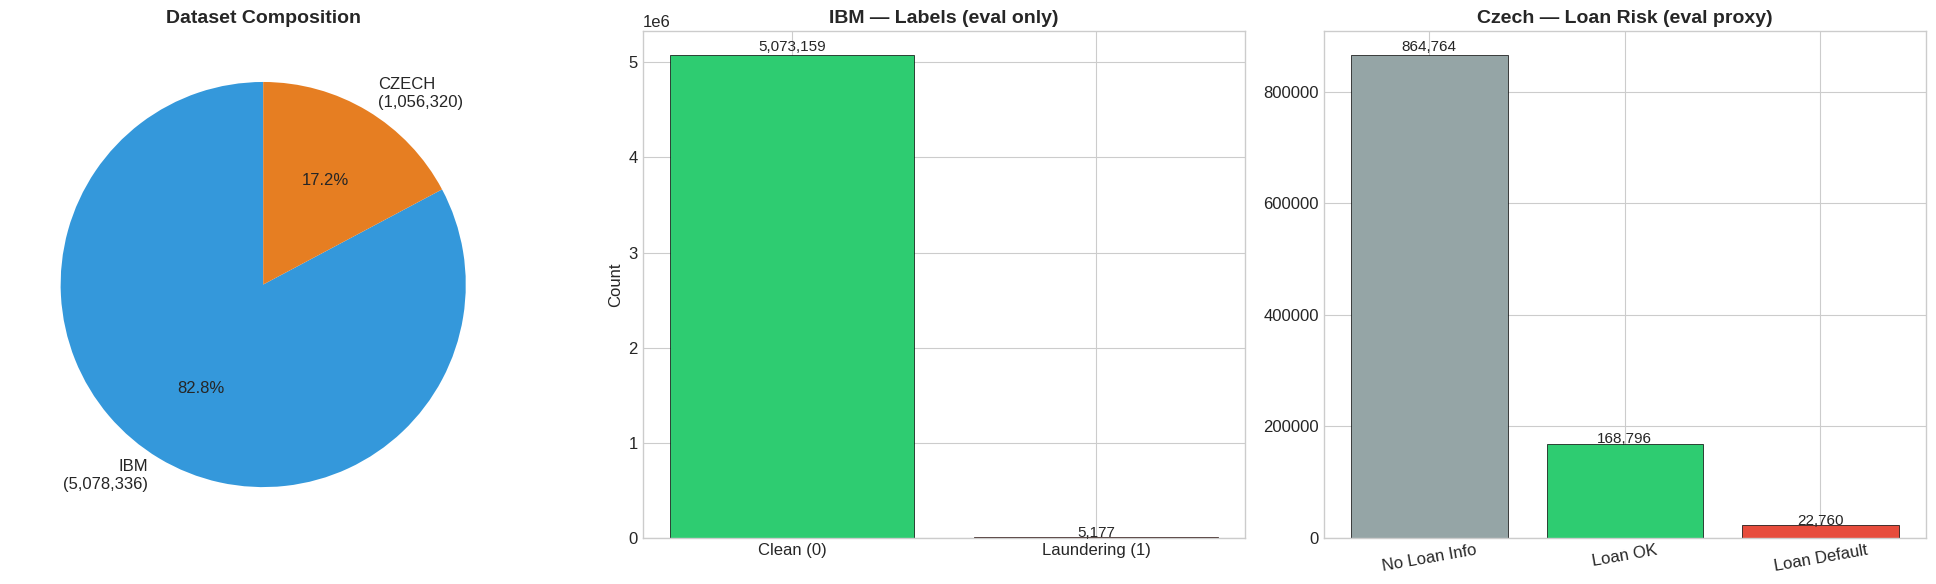

In [ ]:
ibm_d = merged[merged['source']=='ibm']
cz_d = merged[merged['source']=='czech']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Source split
ax = axes[0]
src = merged['source'].value_counts()
ax.pie(src.values, labels=[f"{k.upper()}\n({v:,})" for k,v in src.items()],
       colors=['#3498db','#e67e22'], autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
ax.set_title('Dataset Composition', fontsize=14, fontweight='bold')

# IBM target
ax = axes[1]
lbl = ibm_d['_label'].value_counts().sort_index()
bars = ax.bar(['Clean (0)','Laundering (1)'], lbl.values,
              color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.5)
for b,v in zip(bars, lbl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('IBM — Labels (eval only)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')

# Czech risk
ax = axes[2]
cl = cz_d['_label'].value_counts().sort_index()
nm = {-1:'No Loan Info', 0:'Loan OK', 1:'Loan Default'}
clr = {-1:'#95a5a6', 0:'#2ecc71', 1:'#e74c3c'}
bars = ax.bar([nm[k] for k in cl.index], cl.values, color=[clr[k] for k in cl.index],
              edgecolor='black', linewidth=0.5)
for b,v in zip(bars, cl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'{v:,}', ha='center', fontsize=11)
ax.set_title('Czech — Loan Risk (eval proxy)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('viz1_composition.png', dpi=150, bbox_inches='tight')
plt.show()

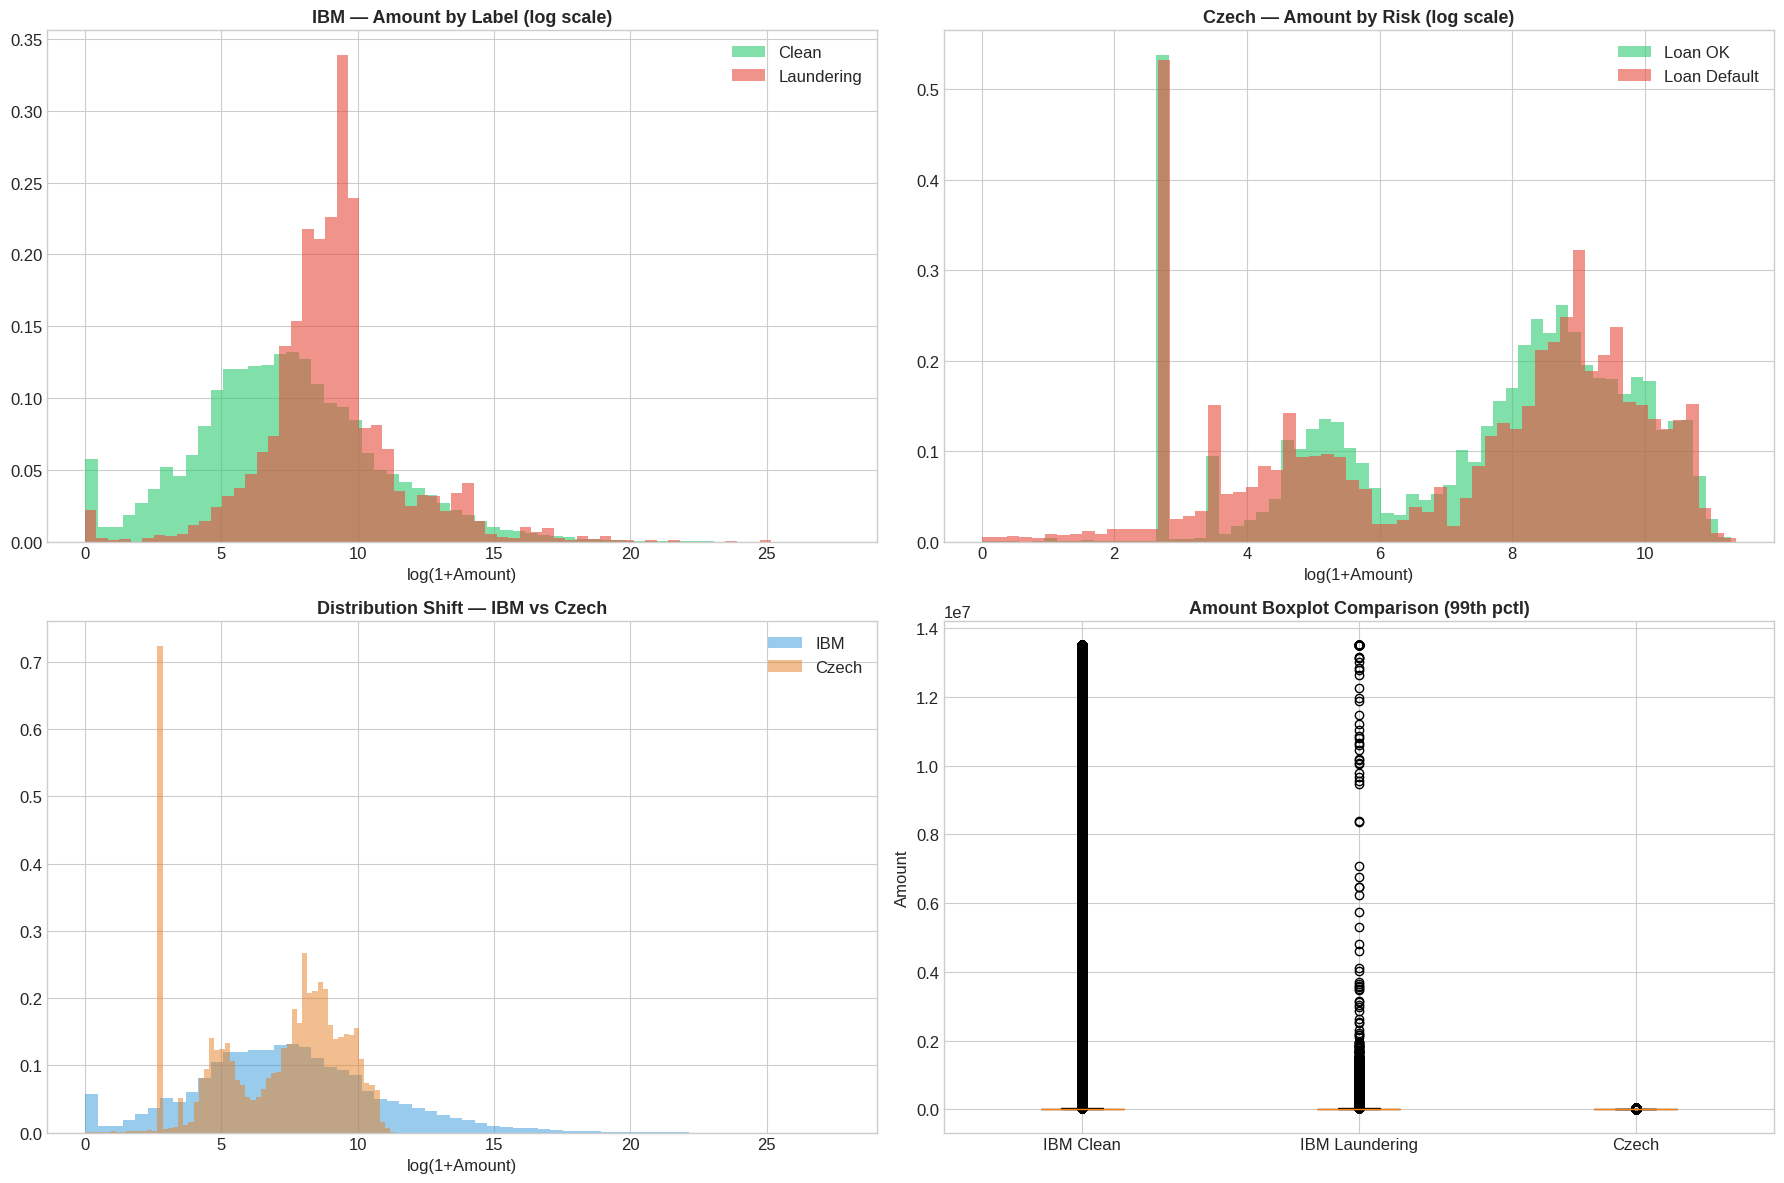

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# IBM clean vs laundering
ax = axes[0,0]
ax.hist(np.log1p(ibm_d[ibm_d['_label']==0]['amount']), bins=60, alpha=0.6, color='#2ecc71', label='Clean', density=True)
ax.hist(np.log1p(ibm_d[ibm_d['_label']==1]['amount']), bins=60, alpha=0.6, color='#e74c3c', label='Laundering', density=True)
ax.set_title('IBM — Amount by Label (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

# Czech by risk
ax = axes[0,1]
czl = cz_d[cz_d['_label']>=0]
if len(czl) > 0:
    ax.hist(np.log1p(czl[czl['_label']==0]['amount']), bins=60, alpha=0.6, color='#2ecc71', label='Loan OK', density=True)
    ax.hist(np.log1p(czl[czl['_label']==1]['amount']), bins=60, alpha=0.6, color='#e74c3c', label='Loan Default', density=True)
ax.set_title('Czech — Amount by Risk (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

# Distribution shift
ax = axes[1,0]
ax.hist(np.log1p(ibm_d['amount'].clip(lower=0)), bins=60, alpha=0.5, color='#3498db', label='IBM', density=True)
ax.hist(np.log1p(cz_d['amount'].clip(lower=0)), bins=60, alpha=0.5, color='#e67e22', label='Czech', density=True)
ax.set_title('Distribution Shift — IBM vs Czech', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1+Amount)'); ax.legend()

# Box plot comparison
ax = axes[1,1]
data_bp = [
    ibm_d[ibm_d['_label']==0]['amount'].clip(upper=ibm_d['amount'].quantile(0.99)),
    ibm_d[ibm_d['_label']==1]['amount'].clip(upper=ibm_d['amount'].quantile(0.99)),
    cz_d['amount'].clip(upper=cz_d['amount'].quantile(0.99)),
]
bp = ax.boxplot(data_bp, labels=['IBM Clean','IBM Laundering','Czech'], patch_artist=True)
for p,c in zip(bp['boxes'], ['#2ecc71','#e74c3c','#e67e22']):
    p.set_facecolor(c); p.set_alpha(0.7)
ax.set_title('Amount Boxplot Comparison (99th pctl)', fontsize=13, fontweight='bold')
ax.set_ylabel('Amount')

plt.tight_layout()
plt.savefig('viz2_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

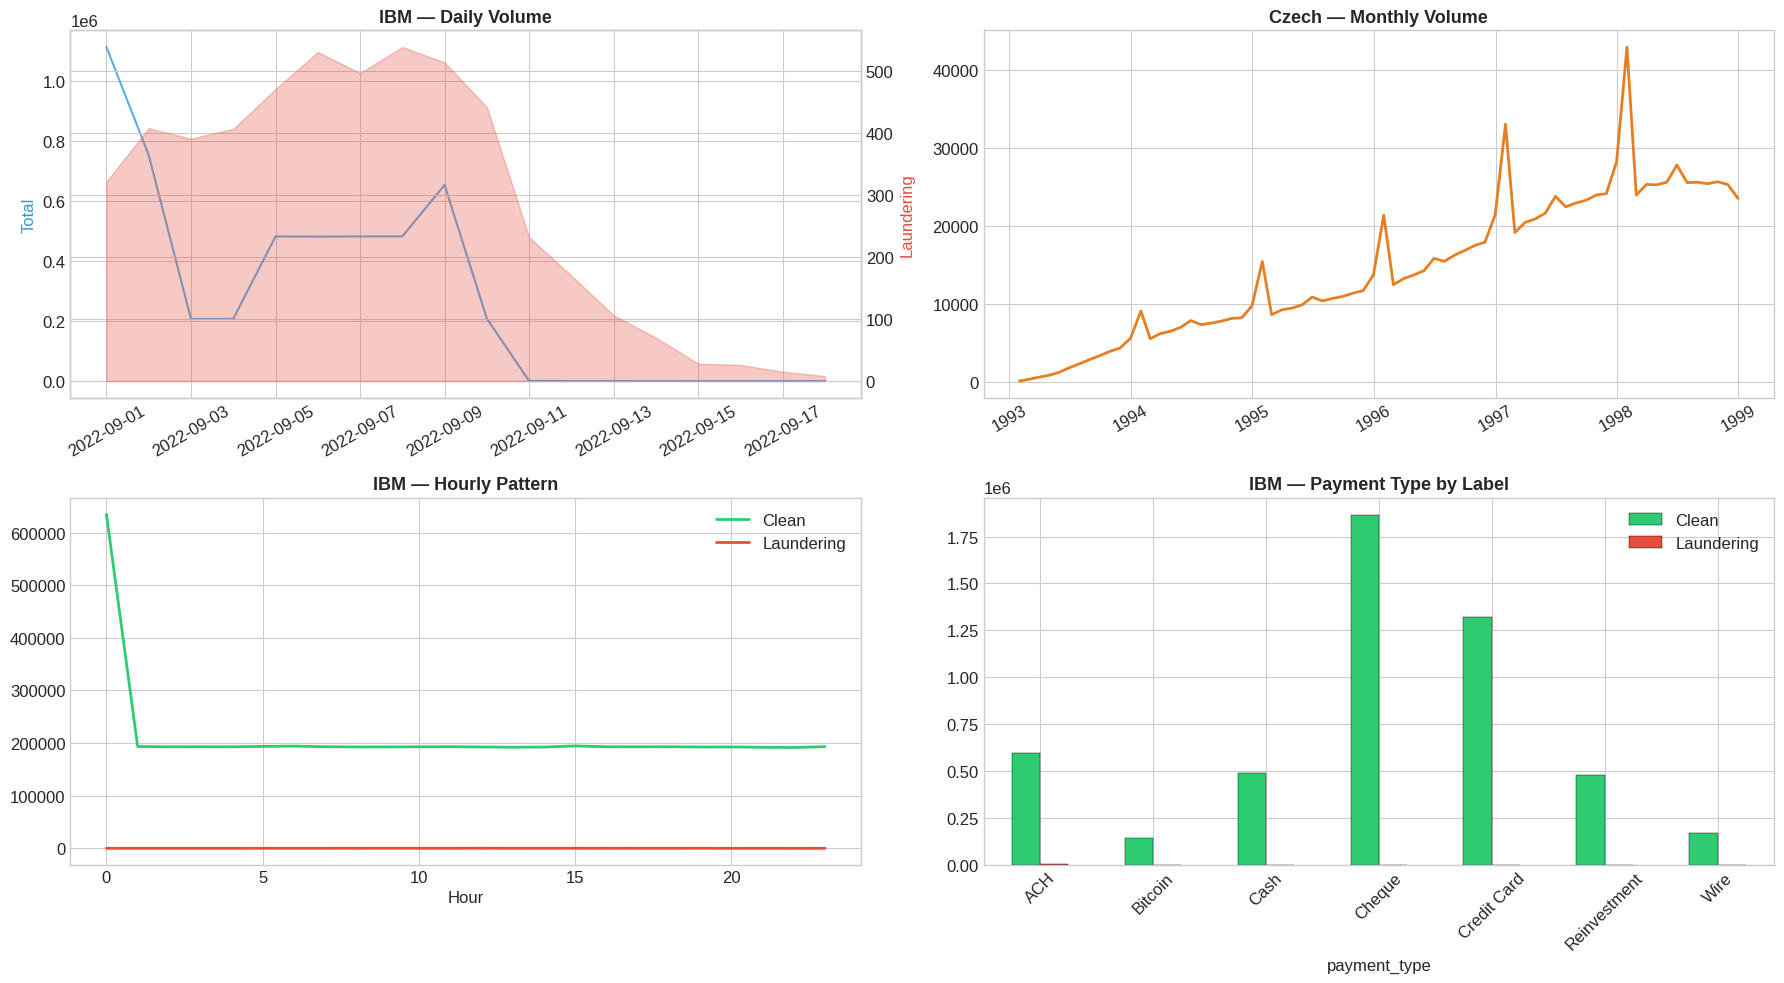

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# IBM daily
ax = axes[0,0]
ibm_daily = ibm_d.set_index('timestamp').resample('D').agg(total=('amount','count'), launder=('_label','sum')).dropna()
ax.plot(ibm_daily.index, ibm_daily['total'], color='#3498db', alpha=0.8)
ax2 = ax.twinx()
ax2.fill_between(ibm_daily.index, ibm_daily['launder'], color='#e74c3c', alpha=0.3)
ax.set_title('IBM — Daily Volume', fontsize=13, fontweight='bold')
ax.set_ylabel('Total', color='#3498db'); ax2.set_ylabel('Laundering', color='#e74c3c')
ax.tick_params(axis='x', rotation=30)

# Czech monthly
ax = axes[0,1]
cz_monthly = cz_d.dropna(subset=['timestamp']).set_index('timestamp').resample('M').size()
ax.plot(cz_monthly.index, cz_monthly.values, color='#e67e22', linewidth=2)
ax.set_title('Czech — Monthly Volume', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# IBM hourly
ax = axes[1,0]
ibm_hourly = ibm_d.groupby([ibm_d['timestamp'].dt.hour,'_label']).size().unstack(fill_value=0)
ibm_hourly.plot(ax=ax, color=['#2ecc71','#e74c3c'], linewidth=2)
ax.set_title('IBM — Hourly Pattern', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour'); ax.legend(['Clean','Laundering'])

# Payment types
ax = axes[1,1]
pt = ibm_d.groupby(['payment_type','_label']).size().unstack(fill_value=0)
pt.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.3)
ax.set_title('IBM — Payment Type by Label', fontsize=13, fontweight='bold')
ax.legend(['Clean','Laundering']); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('viz3_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8A. TRANSACTION-LEVEL FEATURES
# ══════════════════════════════════════════════════════════════
df = merged.copy()

df['amount_log'] = np.log1p(df['amount'].clip(lower=0))
df['amount_recv_log'] = np.log1p(df['amount_received'].clip(lower=0))
df['amount_diff'] = df['amount_received'] - df['amount']
df['amount_ratio'] = (df['amount_received'] / (df['amount'] + 1e-6)).clip(-100, 100)

df['hour'] = df['timestamp'].dt.hour.fillna(0).astype(int)
df['dow'] = df['timestamp'].dt.dayofweek.fillna(0).astype(int)
df['month'] = df['timestamp'].dt.month.fillna(0).astype(int)
df['is_weekend'] = (df['dow'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

df['is_cross_currency'] = (df['currency_send'] != df['currency_recv']).astype(int)
df['payment_enc'] = LabelEncoder().fit_transform(df['payment_type'].astype(str))
df['currency_enc'] = LabelEncoder().fit_transform(df['currency_send'].astype(str))
df['source_enc'] = (df['source'] == 'ibm').astype(int)

# ── 8B. ACCOUNT-LEVEL FEATURES ──
acct = df.groupby('sender_id').agg(
    acct_tx_count=('amount','count'), acct_total_vol=('amount','sum'),
    acct_avg=('amount','mean'), acct_std=('amount','std'),
    acct_max=('amount','max'), acct_min=('amount','min'),
    acct_receivers=('receiver_id','nunique'),
    acct_night_pct=('is_night','mean'), acct_weekend_pct=('is_weekend','mean'),
    acct_cross_curr=('is_cross_currency','mean'),
).reset_index()
acct['acct_std'] = acct['acct_std'].fillna(0)
acct['acct_range'] = acct['acct_max'] - acct['acct_min']
acct['acct_cv'] = acct['acct_std'] / (acct['acct_avg'] + 1e-6)
df = df.merge(acct, on='sender_id', how='left')
df['amt_vs_avg'] = df['amount'] / (df['acct_avg'] + 1e-6)
df['amt_z_score'] = ((df['amount'] - df['acct_avg']) / (df['acct_std'] + 1e-6)).clip(-50, 50)

# ── 8C. NETWORK FEATURES ──
cent_map = nx.degree_centrality(G_ibm)
in_map = dict(G_ibm.in_degree()); out_map = dict(G_ibm.out_degree())
df['g_sender_cent'] = df['sender_id'].map(cent_map).fillna(0)
df['g_sender_in'] = df['sender_id'].map(in_map).fillna(0)
df['g_sender_out'] = df['sender_id'].map(out_map).fillna(0)
df['g_sender_io_ratio'] = df['g_sender_in'] / (df['g_sender_out'] + 1e-6)
df['g_recv_cent'] = df['receiver_id'].map(cent_map).fillna(0)
df['g_recv_in'] = df['receiver_id'].map(in_map).fillna(0)
df['g_recv_out'] = df['receiver_id'].map(out_map).fillna(0)

print(f"✅ All features engineered. Total columns: {len(df.columns)}")

✅ All features engineered. Total columns: 44


In [ ]:
# ── 8D. FINALIZE FEATURE MATRIX ──
exclude = ['_label','timestamp','sender_id','receiver_id','payment_type',
           'currency_send','currency_recv','source','amount_received']
feature_cols = [c for c in df.columns if c not in exclude
                and df[c].dtype in ['float64','int64','int32','float32','int8']]

print(f"Feature set ({len(feature_cols)} features):")
for i,c in enumerate(feature_cols,1): print(f"  {i:2d}. {c}")

X_all = df[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

y_true = df['_label'].copy()
ibm_mask = df['source']=='ibm'
y_ibm = y_true[ibm_mask]
X_ibm_scaled = X_scaled[ibm_mask.values]

print(f"\nTotal: {len(X_all):,} | IBM (evaluable): {ibm_mask.sum():,} | Czech: {(~ibm_mask).sum():,}")

Feature set (35 features):
   1. amount
   2. amount_log
   3. amount_recv_log
   4. amount_diff
   5. amount_ratio
   6. hour
   7. dow
   8. month
   9. is_weekend
  10. is_night
  11. is_cross_currency
  12. payment_enc
  13. currency_enc
  14. source_enc
  15. acct_tx_count
  16. acct_total_vol
  17. acct_avg
  18. acct_std
  19. acct_max
  20. acct_min
  21. acct_receivers
  22. acct_night_pct
  23. acct_weekend_pct
  24. acct_cross_curr
  25. acct_range
  26. acct_cv
  27. amt_vs_avg
  28. amt_z_score
  29. g_sender_cent
  30. g_sender_in
  31. g_sender_out
  32. g_sender_io_ratio
  33. g_recv_cent
  34. g_recv_in
  35. g_recv_out

Total: 6,134,656 | IBM (evaluable): 5,078,336 | Czech: 1,056,320


---
## 9. Unsupervised Anomaly Detection Models

**All models trained on ALL data (IBM+Czech) with ZERO labels.**

In [ ]:
# Helper function
def evaluate_anomaly(name, scores, y_eval):
    print(f"  ROC-AUC: {roc_auc_score(y_eval, scores):.4f}")
    print(f"  PR-AUC:  {average_precision_score(y_eval, scores):.4f}")
    for pct in [90, 95, 97, 99]:
        thresh = np.percentile(scores, pct)
        preds = (scores >= thresh).astype(int)
        p = precision_score(y_eval, preds, zero_division=0)
        r = recall_score(y_eval, preds, zero_division=0)
        f = f1_score(y_eval, preds, zero_division=0)
        print(f"  @{pct}th pctl (flag top {100-pct}%): P={p:.3f} R={r:.3f} F1={f:.3f}")

In [ ]:
# ── MODEL 1: Isolation Forest ──
print("="*65); print("MODEL 1: Isolation Forest"); print("="*65)
iso = IsolationForest(n_estimators=300, contamination='auto', random_state=42, n_jobs=-1)
iso.fit(X_scaled)
iso_scores_all = -iso.decision_function(X_scaled)
iso_scores_ibm = iso_scores_all[ibm_mask.values]
evaluate_anomaly('Isolation Forest', iso_scores_ibm, y_ibm)

MODEL 1: Isolation Forest
  ROC-AUC: 0.6994
  PR-AUC:  0.0018
  @90th pctl (flag top 10%): P=0.002 R=0.171 F1=0.003
  @95th pctl (flag top 5%): P=0.002 R=0.074 F1=0.003
  @97th pctl (flag top 3%): P=0.001 R=0.040 F1=0.003
  @99th pctl (flag top 1%): P=0.001 R=0.015 F1=0.003


In [ ]:
# ── MODEL 3: K-Means Distance ──
print("="*65); print("MODEL 3: K-Means Distance"); print("="*65)
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_scaled)
km_scores_all = km.transform(X_scaled).min(axis=1)
km_scores_ibm = km_scores_all[ibm_mask.values]
evaluate_anomaly('K-Means', km_scores_ibm, y_ibm)

MODEL 3: K-Means Distance
  ROC-AUC: 0.7498
  PR-AUC:  0.0043
  @90th pctl (flag top 10%): P=0.004 R=0.404 F1=0.008
  @95th pctl (flag top 5%): P=0.006 R=0.306 F1=0.012
  @97th pctl (flag top 3%): P=0.009 R=0.251 F1=0.016
  @99th pctl (flag top 1%): P=0.009 R=0.087 F1=0.016


In [ ]:
# ── MODEL 4: Autoencoder ──
print("="*65); print("MODEL 4: Autoencoder (Neural Network)"); print("="*65)
from tensorflow import keras
from tensorflow.keras import layers

n_feat = X_scaled.shape[1]
ae = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(n_feat,)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),  # bottleneck
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_feat, activation='linear'),
])
ae.compile(optimizer='adam', loss='mse')
ae_hist = ae.fit(X_scaled, X_scaled, epochs=30, batch_size=512, validation_split=0.1, verbose=1)

ae_recon = ae.predict(X_scaled, verbose=0)
ae_scores_all = np.mean((X_scaled - ae_recon)**2, axis=1)
ae_scores_ibm = ae_scores_all[ibm_mask.values]
evaluate_anomaly('Autoencoder', ae_scores_ibm, y_ibm)

MODEL 4: Autoencoder (Neural Network)
Epoch 1/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 0.3080 - val_loss: 0.0602
Epoch 2/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.2087 - val_loss: 0.0494
Epoch 3/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 0.1767 - val_loss: 0.0491
Epoch 4/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 0.1848 - val_loss: 0.0558
Epoch 5/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 0.1552 - val_loss: 0.0608
Epoch 6/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.1769 - val_loss: 0.0468
Epoch 7/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.1869 - val_loss: 0.0528
Epoch 8/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - loss: 0.1660 - val_loss: 0.0597
Epoch 9/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.1412 - val_loss: 0.0595
Epoch 10/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.1583 - val_loss: 0.0639
Epoch 11/30
10784/10784 ━━━━━━━━━━━━━━━━━━━━ 26s 2m

---
## 11. Evaluation Visualizations

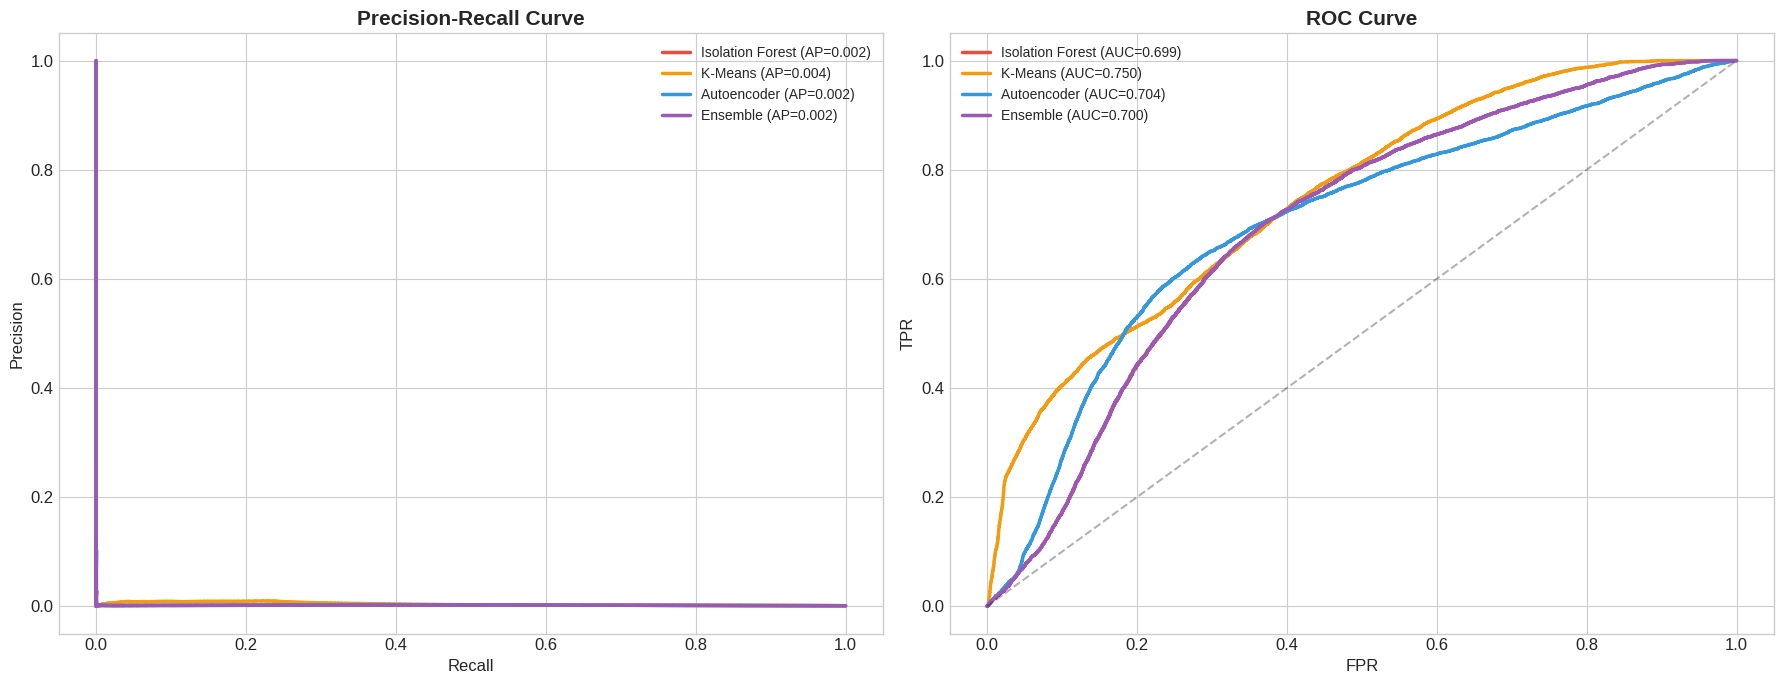

In [ ]:
# ══════════════════════════════════════════════════════════════
# PR + ROC Curves
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

txn_models = {
    'Isolation Forest': (iso_scores_ibm, y_ibm),
    'K-Means': (km_scores_ibm, y_ibm),
    'Autoencoder': (ae_scores_ibm, y_ibm),
    'Ensemble': (ens_scores_ibm, y_ibm),
}
cs = ['#e74c3c','#f39c12','#3498db','#9b59b6','#2ecc71']

for ax_idx, (curve_fn, xlabel, ylabel, title) in enumerate([
    (precision_recall_curve, 'Recall', 'Precision', 'Precision-Recall'),
    (roc_curve, 'FPR', 'TPR', 'ROC'),
]):
    ax = axes[ax_idx]
    for (name, (scores, y_eval)), c in zip(txn_models.items(), cs):
        if curve_fn == precision_recall_curve:
            p,r,_ = curve_fn(y_eval, scores); ap = average_precision_score(y_eval, scores)
            ax.plot(r, p, color=c, linewidth=2.5, label=f'{name} (AP={ap:.3f})')
        else:
            fpr,tpr,_ = curve_fn(y_eval, scores); a = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=c, linewidth=2.5, label=f'{name} (AUC={a:.3f})')
    if curve_fn == roc_curve: ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_title(f'{title} Curve', fontsize=15, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.legend(fontsize=10)

plt.tight_layout(); plt.savefig('eval_curves.png', dpi=150, bbox_inches='tight'); plt.show()

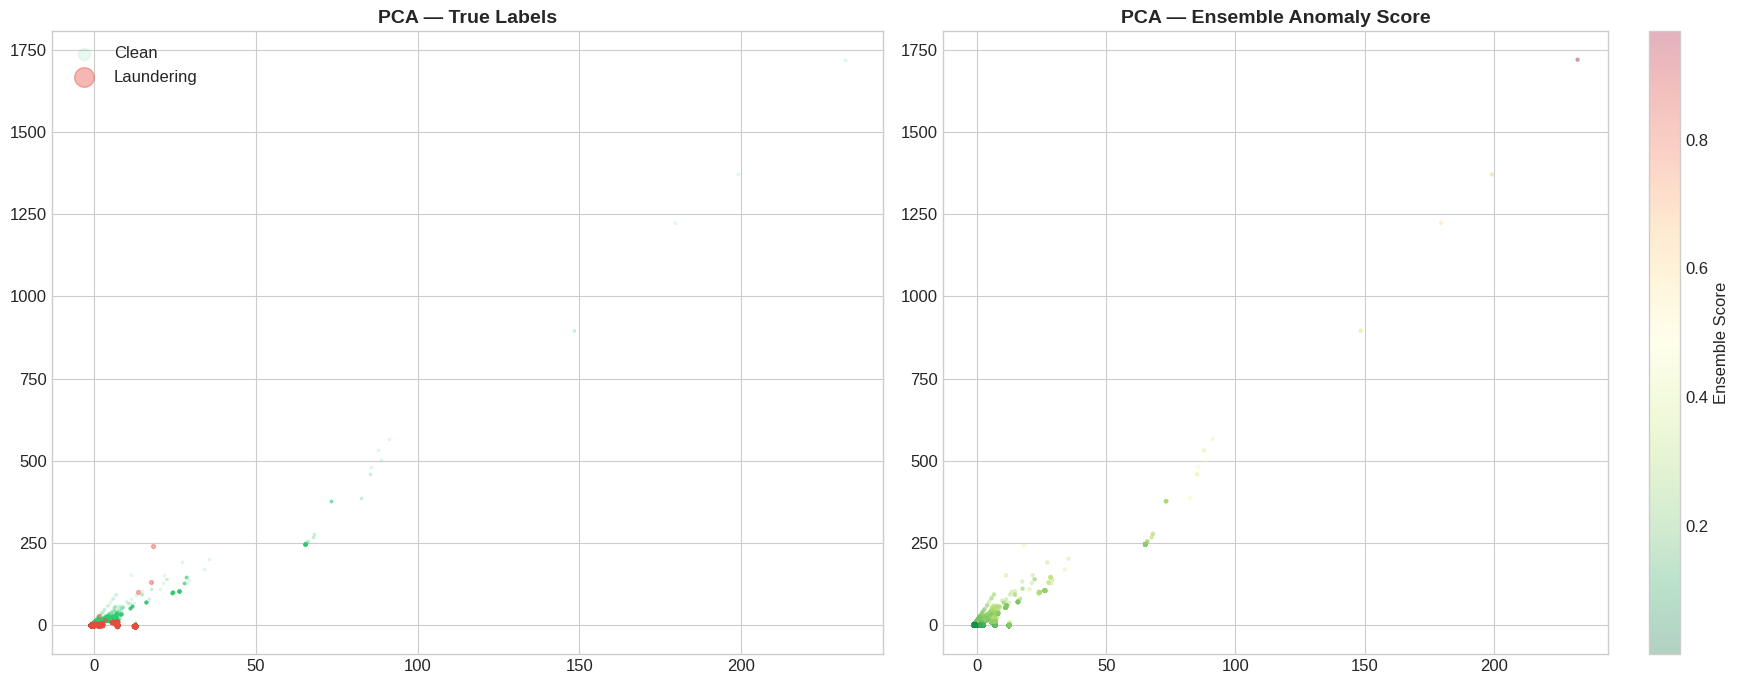

In [ ]:
# ══════════════════════════════════════════════════════════════
# PCA Projection: True Labels vs Anomaly Scores
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_ibm_scaled)

ax = axes[0]
ax.scatter(X_pca[y_ibm.values==0,0], X_pca[y_ibm.values==0,1], c='#2ecc71', alpha=0.1, s=3, label='Clean')
ax.scatter(X_pca[y_ibm.values==1,0], X_pca[y_ibm.values==1,1], c='#e74c3c', alpha=0.4, s=8, label='Laundering')
ax.set_title('PCA — True Labels', fontsize=14, fontweight='bold'); ax.legend(markerscale=5)

ax = axes[1]
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=ens_scores_ibm, cmap='RdYlGn_r', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label='Ensemble Score')
ax.set_title('PCA — Ensemble Anomaly Score', fontsize=14, fontweight='bold')

plt.tight_layout(); plt.savefig('pca_viz.png', dpi=150, bbox_inches='tight'); plt.show()